**Este código te permite:**

Simular la evolución temporal de un sistema de ecuaciones diferenciales con dos variables.

Visualizar las soluciones (curvas de 𝑋(𝑡), 𝑌(𝑡) y 𝑋𝑌(𝑡))en una gráfica.

Interactuar con el modelo modificando los parámetros mediante controles deslizantes, ayuda a entender cómo influyen estos parámetros en el comportamiento del sistema.


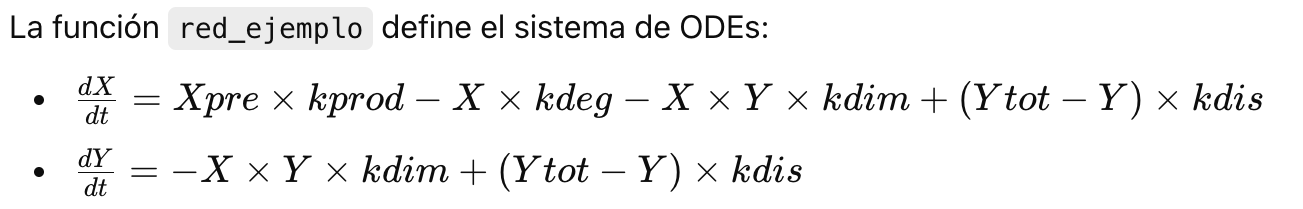

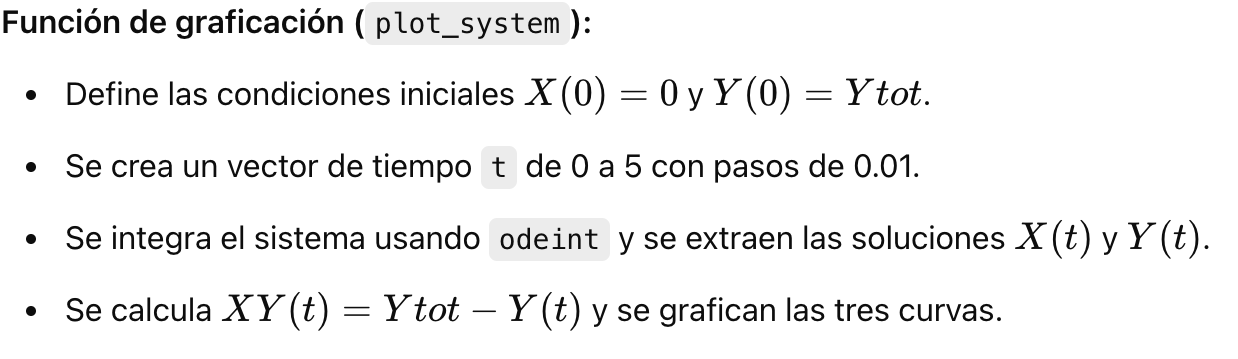

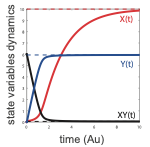

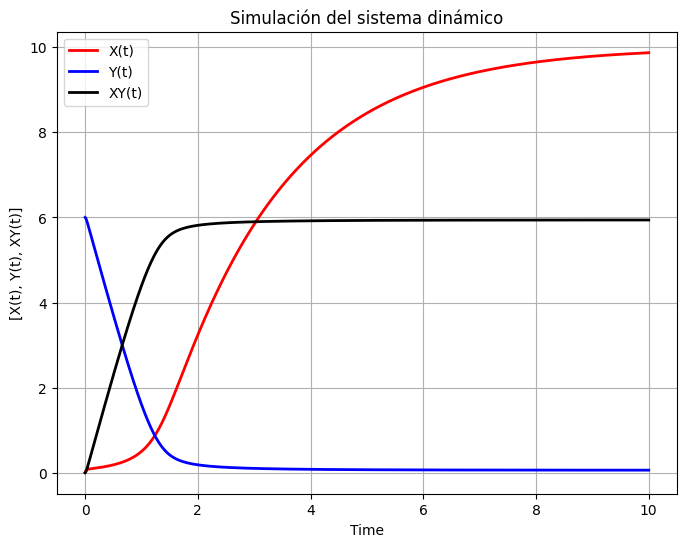

interactive(children=(FloatSlider(value=10.0, description='Xpre', max=20.0, step=0.5), FloatSlider(value=0.5, …

<function __main__.plot_system(Xpre=10, kprod=0.5, kdeg=0.5, kdim=10, kdis=1, Ytot=6)>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from ipywidgets import interact, FloatSlider
%matplotlib inline

def red_ejemplo(y, t, Xpre, kprod, kdeg, kdim, kdis, Ytot):
    """
    Define el sistema de ecuaciones:
      dX/dt = Xpre*kprod - X*kdeg - X*Y*kdim + (Ytot - Y)*kdis
      dY/dt = -X*Y*kdim + (Ytot - Y)*kdis
    """
    X, Y = y
    XY = Ytot - Y
    dX = Xpre * kprod - X * kdeg - X * Y * kdim + XY * kdis
    dY = - X * Y * kdim + XY * kdis
    return [dX, dY]

def plot_system(Xpre=10, kprod=0.5, kdeg=0.5, kdim=10, kdis=1, Ytot=6):
    """
    Integra el sistema en el intervalo t = [0, 5] y grafica las soluciones:
      X(t) en rojo, Y(t) en azul y XY(t) = Ytot - Y(t) en negro.
    """
    # Condiciones iniciales: X(0)=0, Y(0)=Ytot
    y0 = [0, Ytot]
    t = np.arange(0, 10.01, 0.01)  # t de 0 a 10 con paso 0.01
    
    # Integrar el sistema
    sol = odeint(red_ejemplo, y0, t, args=(Xpre, kprod, kdeg, kdim, kdis, Ytot))
    X = sol[:, 0]
    Y = sol[:, 1]
    XY = Ytot - Y

    # Graficar
    plt.figure(figsize=(8,6))
    plt.plot(t, X, 'r-', lw=2, label='X(t)')
    plt.plot(t, Y, 'b-', lw=2, label='Y(t)')
    plt.plot(t, XY, 'k-', lw=2, label='XY(t)')
    plt.xlabel('Time')
    plt.ylabel('[X(t), Y(t), XY(t)]')
    plt.title('Simulación del sistema dinámico')
    plt.legend()
    plt.grid(True)
    plt.show()

# Gráfica por defecto (valores: Xpre=10, kprod=0.5, kdeg=0.5, kdim=10, kdis=1, Ytot=6)
plot_system()

# Interactividad: sliders para modificar los parámetros
interact(plot_system,
         Xpre=FloatSlider(min=0, max=20, step=0.5, value=10, description='Xpre'),
         kprod=FloatSlider(min=0, max=2, step=0.05, value=0.5, description='kprodEprod'),
         kdeg=FloatSlider(min=0, max=2, step=0.05, value=0.5, description='kdegEdeg'),
         kdim=FloatSlider(min=0.1, max=20, step=0.5, value=10, description='kdimEdim'),
         kdis=FloatSlider(min=0, max=5, step=0.1, value=1, description='kdisEdis'),
         Ytot=FloatSlider(min=1, max=20, step=1, value=6, description='Ytot'))


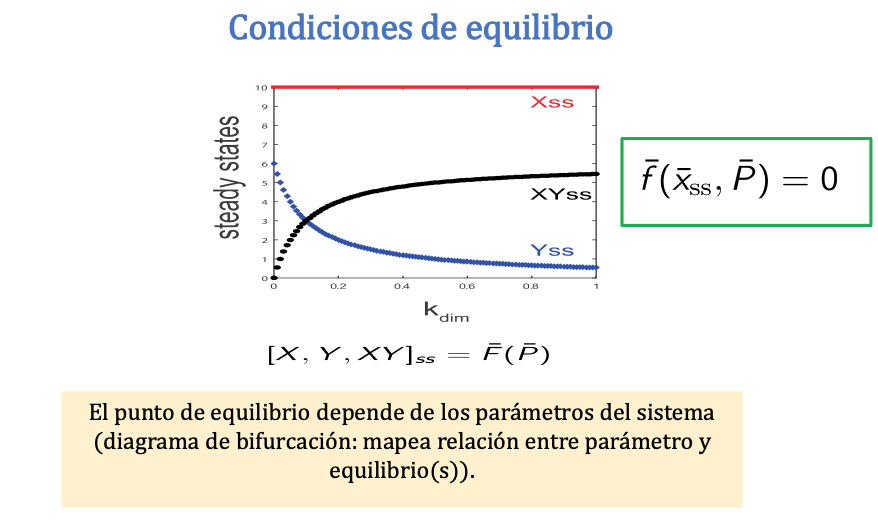
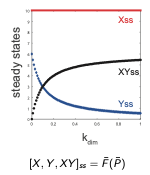

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Para ver las gráficas dentro del notebook
%matplotlib inline

def X_equilibrium(Xpre, kprod, kdeg):
    """
    Equilibrio de X, asumido constante respecto a kdim:
      X* = (Xpre * kprod) / kdeg
    """
    return (Xpre * kprod) / kdeg

def Y_equilibrium(kdim, Xpre, kprod, kdeg, kdis, Ytot):
    """
    A partir de la ecuación en estado estacionario:
      X* Y* kdim = (Ytot - Y*) kdis
    se despeja Y* en función de kdim, asumiendo X* constante.
    """
    Xstar = X_equilibrium(Xpre, kprod, kdeg)
    return (Ytot * kdis) / (Xstar * kdim + kdis)

def XY_equilibrium(kdim, Xpre, kprod, kdeg, kdis, Ytot):
    """
    XY* = Ytot - Y*
    """
    return Ytot - Y_equilibrium(kdim, Xpre, kprod, kdeg, kdis, Ytot)

def plot_equilibria_vs_kdim(Xpre=10, kprod=0.5, kdeg=0.5, kdis=1.0,
                            Ytot=6.0, kdim_min=0.0, kdim_max=1.0):
    """
    Genera la gráfica de los valores de equilibrio (X*, Y*, XY*)
    en función de kdim (eje x).
    - X* = constante (línea roja)
    - Y*(kdim) (curva azul)
    - XY*(kdim) = Ytot - Y*(kdim) (curva negra)
    """
    # Creamos un vector de kdim en el rango indicado
    kdim_values = np.linspace(kdim_min, kdim_max, 300)
    
    # Calculamos los valores de equilibrio
    X_vals = X_equilibrium(Xpre, kprod, kdeg)  # Escalar (constante)
    Y_vals = [Y_equilibrium(k, Xpre, kprod, kdeg, kdis, Ytot) for k in kdim_values]
    XY_vals = [XY_equilibrium(k, Xpre, kprod, kdeg, kdis, Ytot) for k in kdim_values]
    
    # Iniciamos figura
    plt.figure(figsize=(6,5))
    
    # 1) X* en rojo (línea horizontal) para todo el rango de kdim
    plt.plot(kdim_values, [X_vals]*len(kdim_values),
             color='red', linewidth=2, label='Xss')
    
    # 2) Y*(kdim) en azul
    plt.plot(kdim_values, Y_vals, color='blue', linewidth=2, label='Yss')
    
    # 3) XY*(kdim) en negro
    plt.plot(kdim_values, XY_vals, color='black', linewidth=2, label='XYss')
    
    # Configuración de ejes y leyenda
    plt.xlabel(r'$k_{\mathrm{dim}}$')
    plt.ylabel('steady states')
    plt.ylim(0, max(X_vals, Ytot)+1)  # Un poco más arriba del valor máximo
    plt.title('Equilibrio [X, Y, XY] vs. $k_{dim}$')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Interfaz interactiva
interact(
    plot_equilibria_vs_kdim,
    Xpre=FloatSlider(min=0, max=20, step=0.5, value=10, description='Xpre'),
    kprod=FloatSlider(min=0, max=2, step=0.05, value=0.5, description='kprod'),
    kdeg=FloatSlider(min=0.1, max=2, step=0.05, value=0.5, description='kdeg'),
    kdis=FloatSlider(min=0, max=5, step=0.1, value=1.0, description='kdis'),
    Ytot=FloatSlider(min=1, max=20, step=1, value=6.0, description='Ytot'),
    kdim_min=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.0, description='kdim_min'),
    kdim_max=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='kdim_max')
);


interactive(children=(FloatSlider(value=10.0, description='Xpre', max=20.0, step=0.5), FloatSlider(value=0.5, …